In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import optimizers
from tensorflow.keras.utils import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Flatten, Dense, Activation, Input
from tensorflow.keras.models import Sequential, Model
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras import backend as K
K.clear_session()
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import glob, os
import pandas as pd
data = 'C:/Users/User/OneDrive - INSTITUTO TECNOLOGICO METROPOLITANO - ITM (1)/Semestre 2025-2/Fundamentos de Fotónica FUNFOT04-1/Imagenes/Ultimo_Dataset_Multimodo'
os.chdir(data)
files = []     # "files" es una lista que va a contener cada uno de los nombres (str) de las imagenes
for file in glob.glob("*.jpg"):
    files.append(file)

print(len(files))
num_datos = len(files) # número de datos en el dataset
dim = 224 #dimension (dim, dim) Ipunt of VGG16 = 224x224
X = np.zeros(shape=[num_datos, dim, dim, 3], dtype=np.uint8)    # Imagenes
j=0

temps=[]
rads=[]

for i in range(0,num_datos):
    t_ini = files[i].find("T") + 1
    t_fin = files[i].find("C")
    temp_val = float(files[i][t_ini:t_fin])   
    temps.append(temp_val)

    r_ini = files[i].find("R") + 1
    r_fin = files[i].find("mm")
    radio_val = int(files[i][r_ini:r_fin])  
    rads.append(radio_val)

    X[i,:,:,:] = np.asarray(load_img(files[i],
                                    color_mode='rgb', target_size=(dim, dim)))

temps = np.array(temps)
rads = np.array(rads)
print(X.shape)

4027
(4027, 224, 224, 3)


In [5]:
from tensorflow.keras.utils import to_categorical

radios_unicos = np.unique(rads)
num_clases_radio = len(radios_unicos)

radio_to_idx = {r:i for i,r in enumerate(radios_unicos)}
idx_to_radio = {i:r for r,i in radio_to_idx.items()}

# Convertir
radio_idx = np.array([radio_to_idx[r] for r in rads])
radio_cat = to_categorical(radio_idx, num_classes=num_clases_radio)


In [6]:
y_temp = temps.reshape(-1, 1)
y_radio = radio_cat


In [7]:
num_muestras = len(X)

# índice aleatorio
idx = np.random.permutation(num_muestras)

# aplicar shuffle manteniendo correspondencia
X_shuffled = X[idx]
temp_shuffled = y_temp[idx]
radio_shuffled = y_radio[idx]     # one-hot

print(X_shuffled.shape)
print(temp_shuffled.shape)
print(radio_shuffled.shape)


(4027, 224, 224, 3)
(4027, 1)
(4027, 4)


In [8]:
# Divido sets de train, validación y test
from sklearn.model_selection import train_test_split

X_train, X_test, temp_train, temp_test, radio_train, radio_test = train_test_split(
    X_shuffled, temp_shuffled, radio_shuffled, test_size=0.1, random_state=10
)


X_train, X_val, temp_train, temp_val, radio_train, radio_val = train_test_split(
    X_train, temp_train, radio_train, test_size=0.2, random_state=10
)


In [9]:

# Normalizamos X
X_train = X_train/255
X_val = X_val/255
X_test = X_test/255

In [10]:
name = 'Modelo_RegresionSimultanea_MobileNet'

In [11]:
# https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV3Large
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D

In [12]:
# image_input = Input(shape=(224, 224, 3)) Esto es igual que decir base_model.input, porque se lo entramoe en 'input_shape'
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [13]:
def MNet_reg(num):
    # Agregar una capa de aplanamiento y dos capas densas para la regresión
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation="relu")(x)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.1)(x)

    # Salida 1: Temperatura (regresión)
    temp_output = Dense(1, activation="linear", name="temp_output")(x)

    # Salida 2: Radio (clasificación)
    radio_output = Dense(len(radios_unicos), activation="softmax", name="radio_output")(x)

    # Crear un modelo de TensorFlow que incluya la base de la red y las nuevas capas
    model = Model(inputs=base_model.input, outputs=[temp_output, radio_output])


    model.trainable = True
    for layer in model.layers[:-num]:
        layer.trainable = False

    return model

In [14]:
def plot_epochs(history, li, ls):    # li -> limite inferior, ls -> limite superior en y!!!
    plt.figure()
    plt.ylim([li, ls])
    plt.xlabel("Épocas")
    plt.ylabel("MSE")
    plt.plot(history.history['loss'],'bo')
    plt.plot(history.history['val_loss'],'r')

    plt.legend(['Pérdida de entrenamiento', 'Pérdida de validación'], loc='upper right')

In [15]:
def plot_several_epochs(history, steps, title, li, ls, save = False):    # li -> limite inferior, ls -> limite superior en y!!!
    escala = 5
    marker = 2

    fig, axs = plt.subplots(1, len(history), figsize=(escala*1.3*len(history), escala), dpi=65)
    for i in range(len(history)):
        #plt.figure(figsize=(escala, escala), dpi=50)
        #axs[i] = plt.subplots(figsize=(escala, escala))
        #plt.ylim([li, ls])
        axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0,4))   # notación científica
        axs[i].set_ylim([li, ls])
        axs[i].set_xlabel("Epochs")
        axs[i].set_ylabel("Mean Squared Error")
        axs[i].plot(history[i].history['loss'],'bo')
        axs[i].plot(history[i].history['val_loss'],'r')
        axs[i].set_title(title + '= ' + str(round(steps[i], 8)))
        axs[i].legend(['Training loss', 'Validation loss'], loc='upper right')
    if save == True:
        fig.savefig("./images/" + title + ".svg", format="svg")

In [16]:
%%time
# Esta optimización la hacemos con los mejores parámetros encontrados con Optuna


model = MNet_reg(10)
model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss={
        "temp_output": "mse",
        "radio_output": "categorical_crossentropy"
    },
    loss_weights={
        "temp_output": 1.0,
        "radio_output": 1.0
    },
    metrics={
        "temp_output": ["mae"],
        "radio_output": ["accuracy"]
    }
)
history_final = model.fit(X_train, {"temp_output": temp_train, "radio_output": radio_train}, epochs=50, validation_data=(X_val, {"temp_output": temp_val, "radio_output": radio_val}), verbose = 1, batch_size=16)

loss = model.evaluate(X_test, {"temp_output": temp_test, "radio_output": radio_test})

Epoch 1/50
182/182 [==============================] - 11s 21ms/step - loss: 409.8570 - temp_output_loss: 407.8726 - radio_output_loss: 1.9846 - temp_output_mae: 11.9615 - radio_output_accuracy: 0.2625 - val_loss: 30.3596 - val_temp_output_loss: 28.9845 - val_radio_output_loss: 1.3751 - val_temp_output_mae: 4.2019 - val_radio_output_accuracy: 0.3393
Epoch 2/50
182/182 [==============================] - 3s 17ms/step - loss: 51.6954 - temp_output_loss: 49.8083 - radio_output_loss: 1.8871 - temp_output_mae: 5.5502 - radio_output_accuracy: 0.3308 - val_loss: 10.7213 - val_temp_output_loss: 9.5038 - val_radio_output_loss: 1.2175 - val_temp_output_mae: 2.3142 - val_radio_output_accuracy: 0.4759
Epoch 3/50
182/182 [==============================] - 3s 17ms/step - loss: 31.2054 - temp_output_loss: 29.5037 - radio_output_loss: 1.7017 - temp_output_mae: 4.2276 - radio_output_accuracy: 0.3919 - val_loss: 154.1386 - val_temp_output_loss: 153.0269 - val_radio_output_loss: 1.1117 - val_temp_output_ma

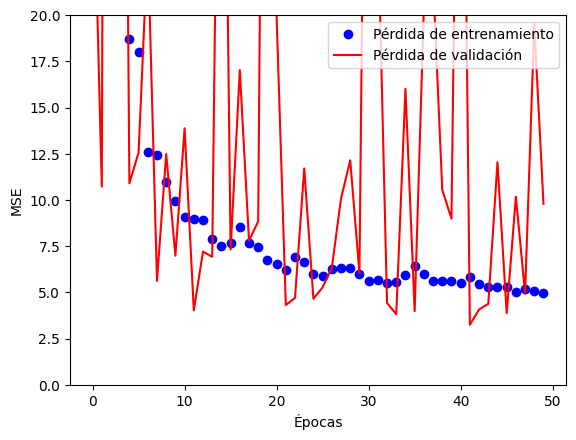

In [17]:
plot_epochs(history_final, 0, 20) # nor

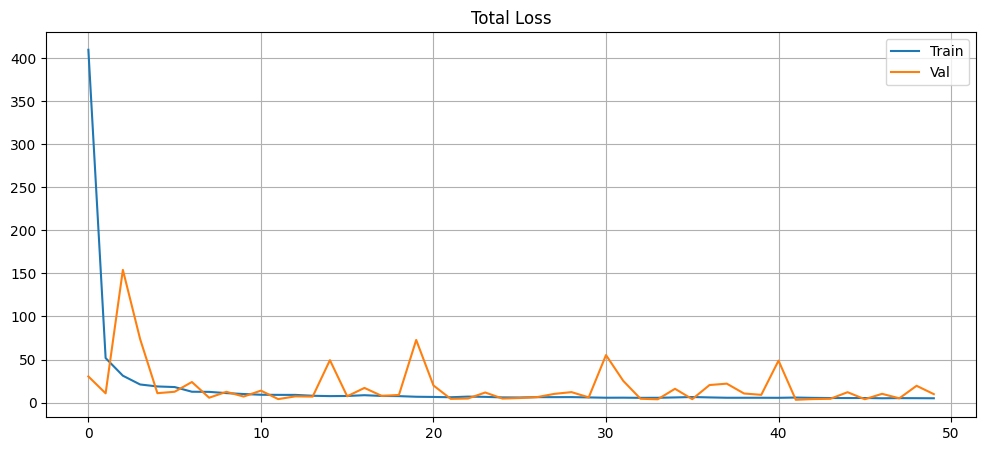

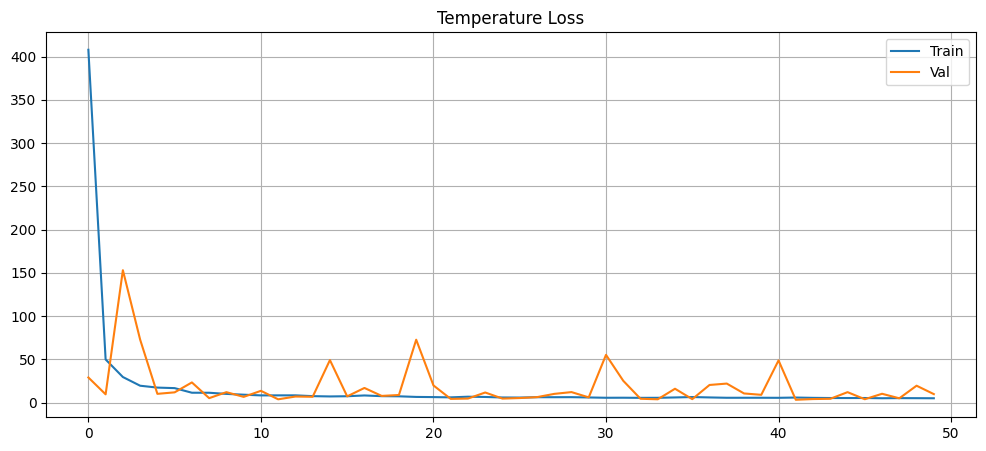

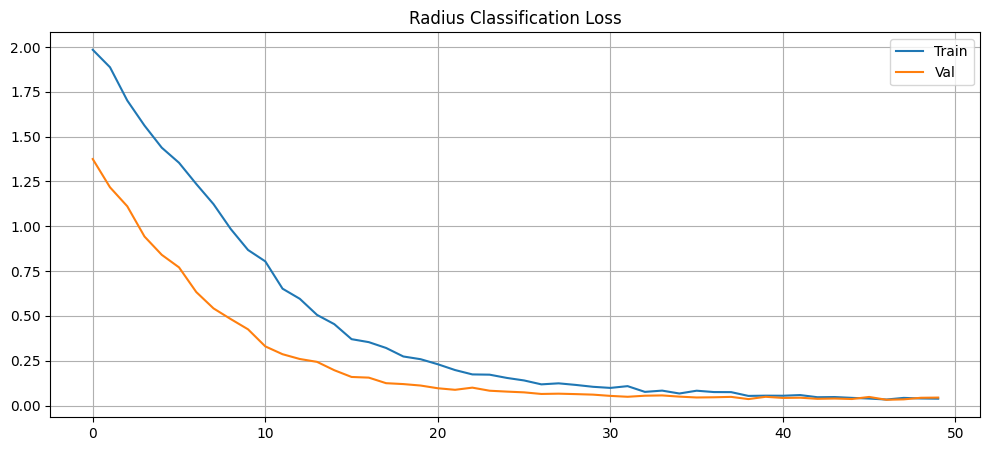

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(history_final.history["loss"])
plt.plot(history_final.history["val_loss"])
plt.title("Total Loss")
plt.legend(["Train","Val"])
plt.grid()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(history_final.history["temp_output_loss"])
plt.plot(history_final.history["val_temp_output_loss"])
plt.title("Temperature Loss")
plt.legend(["Train","Val"])
plt.grid()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(history_final.history["radio_output_loss"])
plt.plot(history_final.history["val_radio_output_loss"])
plt.title("Radius Classification Loss")
plt.legend(["Train","Val"])
plt.grid()
plt.show()


In [19]:
temp_pred_test, radio_pred_test = model.predict(X_test)
radio_pred_idx = np.argmax(radio_pred_test, axis=1)
radio_true_idx = np.argmax(radio_test, axis=1)


13/13 [==============================] - 1s 22ms/step


23/23 [==============================] - 1s 22ms/step


C:\Users\User\AppData\Local\Temp\ipykernel_5584\4023327333.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  linea = np.arange(li, ls, 1)


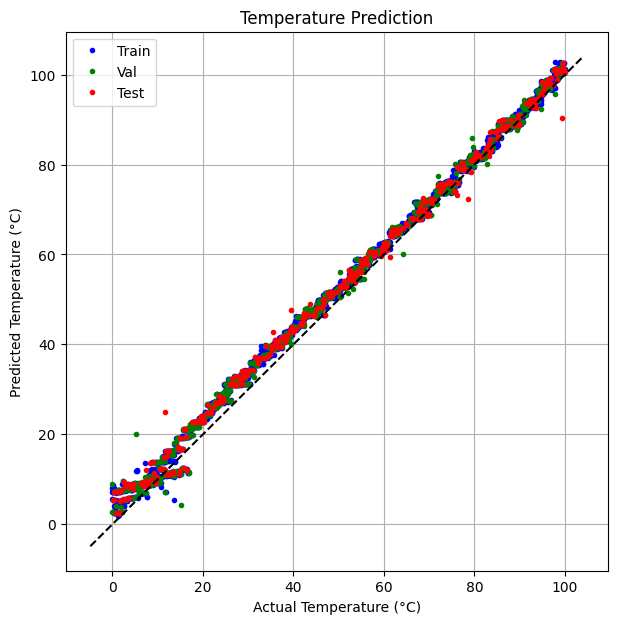

In [20]:
def plot_temp(train_true, train_pred,
              val_true, val_pred,
              test_true, test_pred,
              li, ls, name):

    linea = np.arange(li, ls, 1)

    plt.figure(figsize=(7,7))
    plt.plot(train_true, train_pred, 'b.')
    plt.plot(val_true, val_pred, 'g.')
    plt.plot(test_true, test_pred, 'r.')
    plt.plot(linea, linea, 'k--')
    plt.xlabel("Actual Temperature (°C)")
    plt.ylabel("Predicted Temperature (°C)")
    plt.legend(["Train","Val","Test"])
    plt.grid()
    plt.title("Temperature Prediction")
    plt.savefig(name + ".png")
    plt.show()

plot_temp(temp_train, model.predict(X_train)[0].ravel(),
          temp_val, model.predict(X_val)[0].ravel(),
          temp_test, temp_pred_test.ravel(),
          li=min(temp_test)-5, ls=max(temp_test)+5,
          name="TempPrediction")



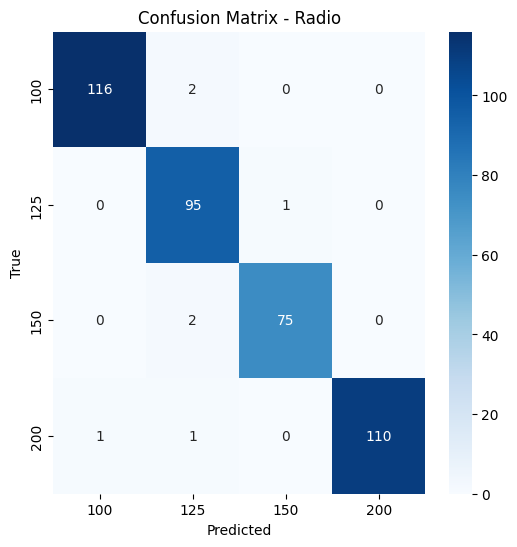

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(radio_true_idx, radio_pred_idx)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=radios_unicos,
            yticklabels=radios_unicos)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Radio")
plt.show()


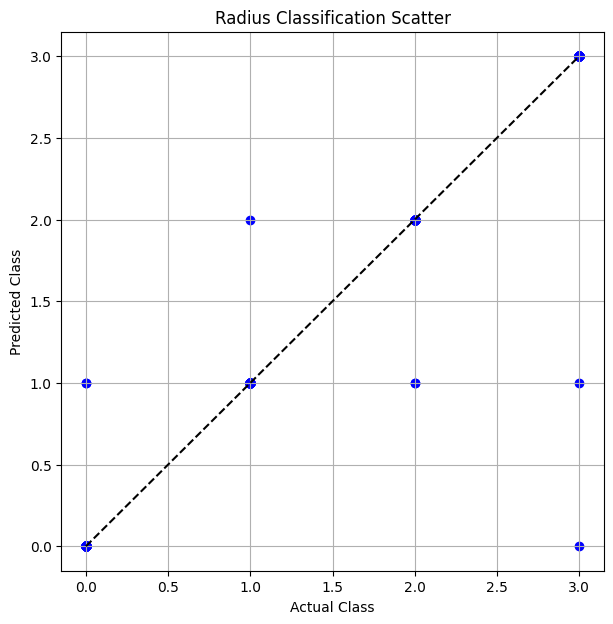

In [22]:
plt.figure(figsize=(7,7))
plt.scatter(radio_true_idx, radio_pred_idx, c="blue")
plt.plot([0, num_clases_radio-1], [0, num_clases_radio-1], 'k--')
plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.title("Radius Classification Scatter")
plt.grid()
plt.show()


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

# Predicciones
temp_pred_test, radio_pred_test = model.predict(X_test)

# Temperature
mae_temp = mean_absolute_error(temp_test, temp_pred_test)
rmse_temp = np.sqrt(mean_squared_error(temp_test, temp_pred_test))

# Radio
radio_pred_idx = np.argmax(radio_pred_test, axis=1)
radio_true_idx = np.argmax(radio_test, axis=1)
acc_radio = accuracy_score(radio_true_idx, radio_pred_idx)

print("\n=== MÉTRICAS CON SKLEARN ===")
print(f"MAE Temperatura:  {mae_temp:.4f}")
print(f"RMSE Temperatura: {rmse_temp:.4f}")
print(f"Accuracy Radio:  {acc_radio*100:.2f} %")

13/13 [==============================] - 0s 22ms/step

=== MÉTRICAS CON SKLEARN ===
MAE Temperatura:  2.7390
RMSE Temperatura: 3.1841
Accuracy Radio:  98.26 %
